# LING 498 Hackathon — Prompt 8

## Grammar rules (Treebank productions)

**Category:** Syntax (constituency)

**Question:** Are phrase-structure productions Zipf-like? What do “stop-rules” and rare rules represent?

- **Data:** NLTK Treebank: treebank.parsed_sents() (use a subset, e.g., first 200).
- **Items to Count:** `str(p)` for each production p in `tree.productions()`.

**Steps**
- Load a subset of parsed sentences.
- Collect productions from each parse tree.
- Run Zipf report/plot.
- Interpret: frequent rules as grammar “infrastructure”; rare rules as marked constructions/annotation detail.

**Deliverable:** Top-15 productions + 2 theoretical takeaways + 1 annotation limitation.

In [10]:
import re
from nltk import FreqDist
from nltk.corpus import treebank

In [11]:
# Helper functions
def zipf_prep(items, min_count=1):
    fd = FreqDist(items)
    # drop ultra-rare if desired
    items2 = [(k,v) for k,v in fd.items() if v >= min_count]
    items2.sort(key=lambda kv: kv[1], reverse=True)
    return items2  # list of (item, count) sorted

def zipf_quick_report(items, title="", topn=15):
    ranked = zipf_prep(items)
    print(f"\n=== {title} ===")
    print(f"Production Types: {len(ranked)} | Productions: {sum(c for _,c in ranked)}")
    print("Top productions:")
    for i,(k,v) in enumerate(ranked[:topn], start=1):
        print(f"{i:>2}. {str(k)[:40]:<40} {v}")
    # simple “Zipf-ness” sanity check (no regression): f1 ~ 2*f2 ~ 3*f3?
    if len(ranked) >= 5:
        f1,f2,f3,f4,f5 = [ranked[i][1] for i in range(5)]
        print("\nHeuristic ratios (closer to 1 is more Zipf-like):")
        print(" f1/(2*f2) =", round(f1/(2*f2), 3))
        print(" f1/(3*f3) =", round(f1/(3*f3), 3))
        print(" f1/(4*f4) =", round(f1/(4*f4), 3))
        print(" f1/(5*f5) =", round(f1/(5*f5), 3))
    return ranked

# Optional plotting cell (instructor can pre-enable if matplotlib is available)
def zipf_plot(ranked, n=1000, title="Top 1000 _______"):
    import matplotlib.pyplot as plt
    ranks = list(range(1, min(n, len(ranked))+1))
    freqs = [ranked[i-1][1] for i in ranks]
    plt.figure(figsize=(6,4))
    plt.loglog(ranks, freqs, marker='.')
    plt.xlabel("rank (log)")
    plt.ylabel("frequency (log)")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    
# regular-scale plot 
def zipf_plot_2(ranked, n=30, title="Phoneme Frequency by Rank"):
    import matplotlib.pyplot as plt
    number_to_plot = min(n, len(ranked))
    ranks = list(range(1, number_to_plot + 1))
    frequencies = []
    for i in ranks:
        frequencies.append(ranked[i - 1][1])
    plt.figure(figsize=(8, 5))
    plt.plot(ranks, frequencies, marker="o")
    plt.xlabel("Rank (1 = most common phoneme)")
    plt.ylabel("Frequency (token count)")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [12]:
# Load a subset of parsed sentences
trees = treebank.parsed_sents()[:20]
sample_tree = trees[0]
print(sample_tree)

(S
  (NP-SBJ
    (NP (NNP Pierre) (NNP Vinken))
    (, ,)
    (ADJP (NP (CD 61) (NNS years)) (JJ old))
    (, ,))
  (VP
    (MD will)
    (VP
      (VB join)
      (NP (DT the) (NN board))
      (PP-CLR (IN as) (NP (DT a) (JJ nonexecutive) (NN director)))
      (NP-TMP (NNP Nov.) (CD 29))))
  (. .))


In [13]:
# Extract productions from the sample tree
sample_productions = [
    str(production)
    for production in sample_tree.productions()
]
print(sample_productions)

['S -> NP-SBJ VP .', 'NP-SBJ -> NP , ADJP ,', 'NP -> NNP NNP', "NNP -> 'Pierre'", "NNP -> 'Vinken'", ", -> ','", 'ADJP -> NP JJ', 'NP -> CD NNS', "CD -> '61'", "NNS -> 'years'", "JJ -> 'old'", ", -> ','", 'VP -> MD VP', "MD -> 'will'", 'VP -> VB NP PP-CLR NP-TMP', "VB -> 'join'", 'NP -> DT NN', "DT -> 'the'", "NN -> 'board'", 'PP-CLR -> IN NP', "IN -> 'as'", 'NP -> DT JJ NN', "DT -> 'a'", "JJ -> 'nonexecutive'", "NN -> 'director'", 'NP-TMP -> NNP CD', "NNP -> 'Nov.'", "CD -> '29'", ". -> '.'"]


In [14]:
# Remove punctuation productions from the sample tree
sample_productions = [
    production
    for production in sample_productions
    if not re.search(r"->\s*'[,.:;!?]'", production)
    and not re.search(r"\s[.,:;!?]$", production)
]
print(sample_productions)

['NP -> NNP NNP', "NNP -> 'Pierre'", "NNP -> 'Vinken'", 'ADJP -> NP JJ', 'NP -> CD NNS', "CD -> '61'", "NNS -> 'years'", "JJ -> 'old'", 'VP -> MD VP', "MD -> 'will'", 'VP -> VB NP PP-CLR NP-TMP', "VB -> 'join'", 'NP -> DT NN', "DT -> 'the'", "NN -> 'board'", 'PP-CLR -> IN NP', "IN -> 'as'", 'NP -> DT JJ NN', "DT -> 'a'", "JJ -> 'nonexecutive'", "NN -> 'director'", 'NP-TMP -> NNP CD', "NNP -> 'Nov.'", "CD -> '29'"]


In [15]:
# Collect productions from all parse trees
productions = []

for tree in trees:
    for production in tree.productions():
        productions.append(str(production))

# Remove punctuation productions
productions = [
    production
    for production in productions
    if not re.search(r"->\s*'[,.:;!?]'", production)
    and not re.search(r"\s[.,:;!?]$", production)
]
print(productions[:20])

['NP -> NNP NNP', "NNP -> 'Pierre'", "NNP -> 'Vinken'", 'ADJP -> NP JJ', 'NP -> CD NNS', "CD -> '61'", "NNS -> 'years'", "JJ -> 'old'", 'VP -> MD VP', "MD -> 'will'", 'VP -> VB NP PP-CLR NP-TMP', "VB -> 'join'", 'NP -> DT NN', "DT -> 'the'", "NN -> 'board'", 'PP-CLR -> IN NP', "IN -> 'as'", 'NP -> DT JJ NN', "DT -> 'a'", "JJ -> 'nonexecutive'"]



=== Treebank Grammar Productions ===
Production Types: 444 | Productions: 836
Top productions:
 1. PP -> IN NP                              24
 2. DT -> 'the'                              22
 3. IN -> 'of'                               19
 4. NP -> NP PP                              12
 5. S -> NP-SBJ VP                           12
 6. NP -> DT NN                              11
 7. NP-SBJ -> -NONE-                         11
 8. DT -> 'a'                                9
 9. IN -> 'in'                               9
10. NP -> NN                                 8
11. NP -> -NONE-                             8
12. PP-LOC -> IN NP                          8
13. S -> -NONE-                              8
14. VBD -> 'said'                            8
15. -NONE- -> '*'                            7

Heuristic ratios (closer to 1 is more Zipf-like):
 f1/(2*f2) = 0.545
 f1/(3*f3) = 0.421
 f1/(4*f4) = 0.5
 f1/(5*f5) = 0.4


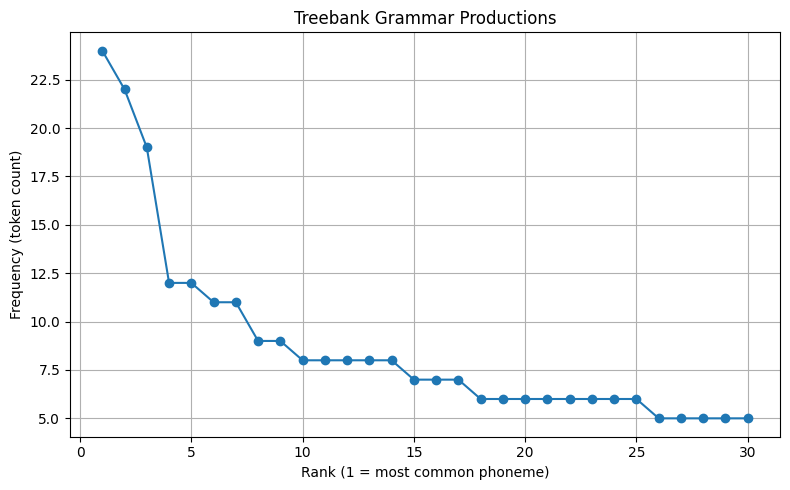

In [16]:
ranked = zipf_quick_report(productions,title="Treebank Grammar Productions")
# zipf_plot(ranked,title="Treebank Grammar Productions")
zipf_plot_2(ranked,title="Treebank Grammar Productions")

### Interpretation

The distribution of grammar productions follows a Zipf-like pattern, with a small number of productions occurring much more frequently than the rest. The most common production is `PP -> IN NP`, showing that prepositional phrases are very common in English. The results also include frequent lexical productions such as `DT -> 'the'` and `IN -> 'of'`, reflecting the high frequency of common function words in the Treebank.

**Theoretical takeaways**

1. English syntax relies on a relatively small number of common phrase-structure rules, such as `PP -> IN NP` and `NP -> DT NN`, which are reused throughout the corpus.

2. Grammar productions capture both syntactic structure and lexical information, so they provide a more thorough representation of language than words or POS tags alone.

**Annotation limitation**

The Penn Treebank uses its own annotation labels, such as `NP-SBJ` and `-NONE-`. These labels are part of the annotation system rather than English grammar itself, so they affect which productions appear most frequently.